# 29 — `hexbin`

`Map.hexbin` lays a **fixed hexagonal lattice** over the points and colours each cell by a reduction of what
falls inside. Hexagons have no preferred direction and share an edge with all six neighbours, so clusters read as
blobs instead of the blocky artefacts a square grid produces.

Where `quadtree` adapts its cells to the data, `hexbin` keeps every cell the same size — which makes cells
directly comparable and the map readable as a density surface.

API: [`Map.hexbin`](../../reference/static_map.md).

> **Where this data comes from.** Everything in this notebook is real, downloaded with
> [earthlens](https://github.com/serapeum-org/earthlens) and committed under `examples/data/`.
> `examples/data/ATTRIBUTION.md` records each source and its licence.


**Setup**.

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
from pyramids.feature import FeatureCollection

from digitalearth.static import Map

# The notebook's own folder is the kernel's working directory, so the bundled
# example data sits three levels up: docs/examples/plots -> repo root.
DATA = Path("../../../examples/data")

# UTM zone 32N: a metric CRS, correct for south-west Germany. Distance-based
# renders (Voronoi, hex lattices, kernels) must not be computed in degrees.
UTM32 = 25832


## The data

The same 3,000 GBIF records, so this can be compared directly with the quadtree.

In [2]:
birds = FeatureCollection.read_file(str(DATA / "heidelberg_birds_2023.geojson"))
print(f"{len(birds)} bird records, {birds['species'].nunique()} species, EPSG:{birds.crs.to_epsg()}")
birds[["species", "eventDate", "uncertainty_m"]].head()

3000 bird records, 111 species, EPSG:4326


,species,eventDate,uncertainty_m
0,Corvus corone,2023-01-11 12:27:25+00:00,NaN
1,Cyanistes caeruleus,2023-01-11 15:49:00+00:00,8.0
2,Phalacrocorax carbo,2023-01-11 11:58:48+00:00,NaN
3,Cyanistes caeruleus,2023-01-11 15:49:04+00:00,8.0
4,Alopochen aegyptiaca,2023-01-11 11:56:46+00:00,NaN


## Quickstart — counting points per cell

With no `column`, `hexbin` colours each cell by **how many points fall in it**. That is the pure density
reading, and with 3,000 records it is a real surface rather than a scatter.

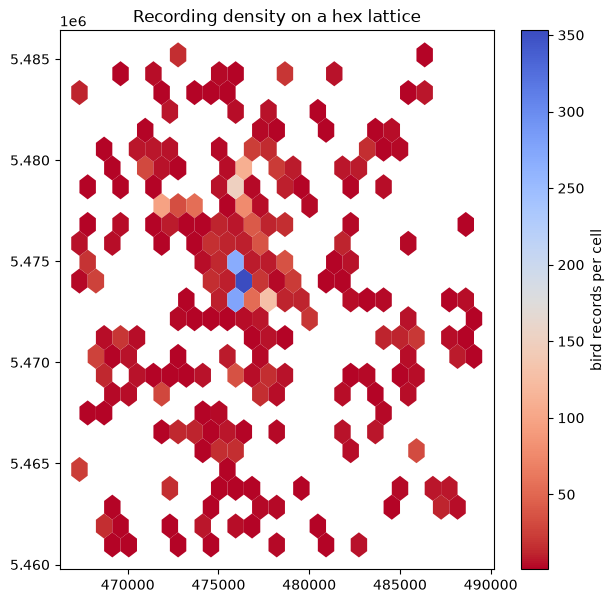

In [3]:
m = Map(crs=UTM32, figsize=(7, 7))
m.hexbin(birds, gridsize=24)
m.colorbar(label="bird records per cell")
m.set_title("Recording density on a hex lattice")
m.fig;

The bright core is Heidelberg itself and the ribbon running out of it is the Neckar valley. This is what `hexbin`
is for: at 3,000 points a scatter plot would be a solid blob over the city and tell you nothing about how much
denser the centre is than the edge.

## Reducing a value instead of counting

Pass a column and `hexbin` colours each cell by a **reduction over that column**.

| argument | meaning | typical value |
|---|---|---|
| `column` | attribute to reduce | `None` (count) or a numeric column |
| `reduce` | how to combine the values in a cell | `"mean"` (default), `"max"`, `"sum"`, or a callable |
| `gridsize` | cells across the x range — the lattice resolution | `50` (default); smaller = coarser |
| `min_count` | hide cells with fewer than this many points | `None` |

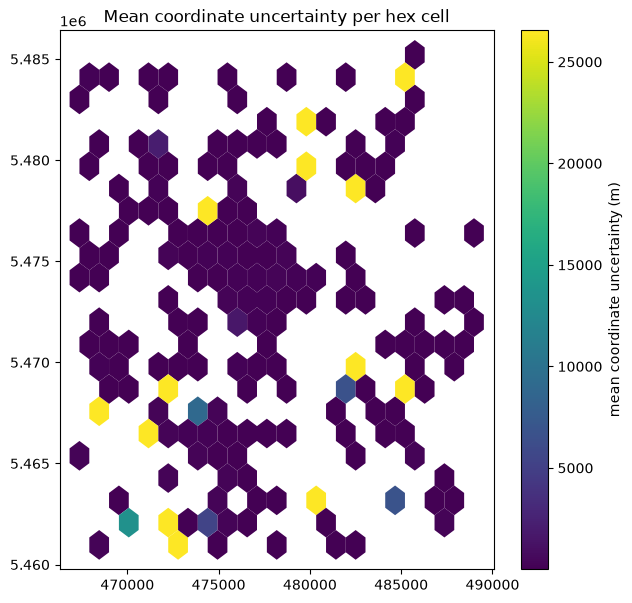

In [4]:
m = Map(crs=UTM32, figsize=(7, 7))
m.hexbin(birds, "uncertainty_m", reduce="mean", gridsize=20, cmap="viridis")
m.colorbar(label="mean coordinate uncertainty (m)")
m.set_title("Mean coordinate uncertainty per hex cell")
m.fig;

Now colour is precision, not density, on equal-area cells — the urban records are tightly located, the rural
ones much vaguer. Because the cells are all the same size, two cells' colours are directly comparable, which is
the advantage over the adaptive quadtree.

## `gridsize` — the resolution dial

`gridsize` counts cells across the horizontal extent. Too coarse and real structure is averaged away; too fine
and most cells hold one point, so the map degenerates back toward a scatter.

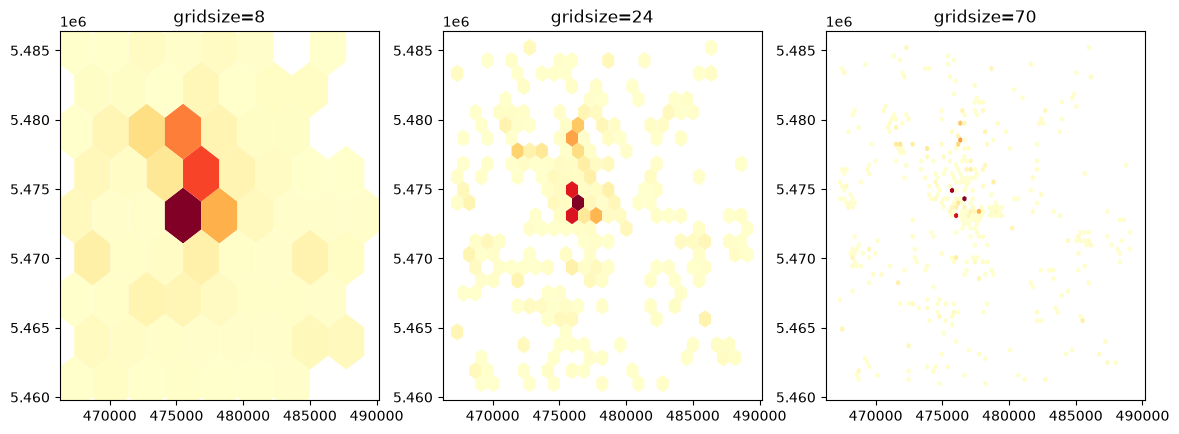

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
for ax, gridsize in zip(axes, (8, 24, 70)):
    panel = Map(ax=ax, crs=UTM32)
    panel.hexbin(birds, gridsize=gridsize, cmap="YlOrRd")
    ax.set_title(f"gridsize={gridsize}")
fig;

At 8 the whole city is one blob; at 70 the lattice is finer than the data and the valley breaks into speckle.
Around 24 is where this many points support a cell. The rule of thumb is to aim for a median of roughly five to
ten points per occupied cell.

## Suppressing thin cells with `min_count`

A cell holding one record reports that record with no averaging, so outliers masquerade as regional signal.
`min_count` drops those cells entirely.

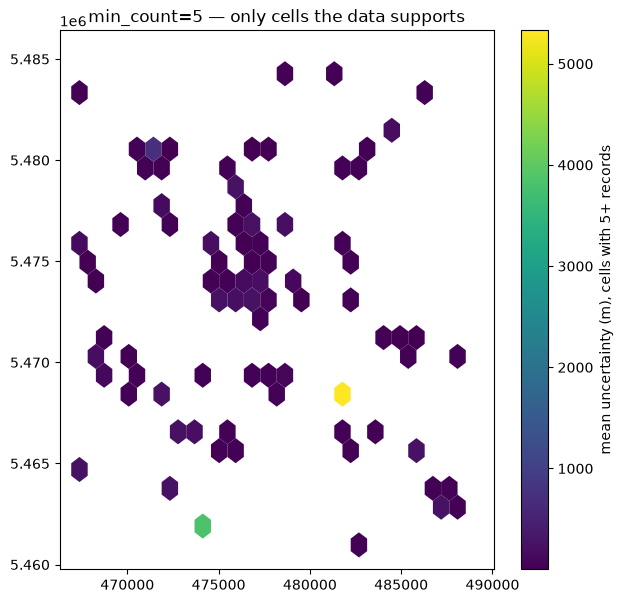

In [6]:
m = Map(crs=UTM32, figsize=(7, 7))
m.hexbin(birds, "uncertainty_m", gridsize=24, min_count=5, cmap="viridis")
m.colorbar(label="mean uncertainty (m), cells with 5+ records")
m.set_title("min_count=5 — only cells the data supports")
m.fig;

What remains is the part of the map the data actually backs: the city and the valley. Everything dropped was a
one- or two-record cell. This is the honest version of the same figure, and it is worth preferring by default.

## Takeaway

- No `column` → **counts** (density). With a `column` → a **reduction** of it per cell.
- `gridsize` sets resolution; target several points per occupied cell.
- `min_count` removes cells too thin to mean anything — reach for it rather than letting single points colour
  a region.
- Equal-sized hexagons make cells comparable, which an adaptive `quadtree` cannot offer.

Next: [`30_kde`](30_kde.ipynb) replaces discrete bins with a continuous surface.